# Leave-k-out validation (Phases A + D)

Quantitative comparison of inverse-Ising models against three naive baselines (marginal usage, co-occurrence weight, PPMI weight) on a held-out test set. For each test team and each $k \in \{1, 2, 3\}$, hold out $k$ random species, score every candidate completion under each model, and measure top-K hit rate + mean reciprocal rank.

Two Ising models are compared head-to-head:

- **Ising species** (Phase 2): PL fit on the species-only vocab — the model that runs in `app.py:load_model_phase2`.
- **Ising item-pair** (Phase 3): PL fit on `(species, item)` pair vocab — the model that runs in `app.py:load_model_phase3`. Restores held-item forme distinctions that the species-only vocab collapses. Evaluation is at **species granularity** for fair cross-model comparison: the item-pair model's species score is $\sum_i P((\text{species}, i) \text{ in team})$ (mutually exclusive events under the uniqueness constraint, so this is exact under the model — though MF computes it approximately).

**Train/test split**: chronological 90/10. Tournaments are sorted oldest-first; the oldest ~90% of teams (by tournament boundary) form the train set, the newest ~10% form the test set. This is the honest out-of-time evaluation: the model is fit on past data and tested on future data it has never seen.

**Methodology notes**:
- Vocab is built on the **train set only** — species or pairs that only appear in future test tournaments are treated as out-of-vocab (test teams with any OOV member are dropped). Cutoff is `PHASE2_MIN_TEAM_COUNT`.
- Model parameters $(J, h)$ are fit on **train only** — no test-set leakage in the fit.
- Model marginals at inference use mean-field iteration. Ranking-preserving without the team-size constraint, since the constraint adds a global Lagrange multiplier identical across candidates; fast (sub-second per test instance, vs minutes for full PT).

In [ ]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from k2dex import helpers
from k2dex import tournament_ingest
from k2dex.constants import SPECIES_ITEM_LR_C, SPECIES_LR_C, PHASE2_MIN_TEAM_COUNT
from k2dex.models import fit_pl_ising

tournaments = tournament_ingest.load_cached_tournaments()
print(f"tournaments:           {len(tournaments)}")
print(f"total team-appearances: {sum(len(t.teams) for t in tournaments)}")

## Train/test split

**Chronological 90/10** at tournament boundaries. Tournaments are sorted oldest-first; the split walks forward until ~90% of total teams are accumulated, then cuts. Everything before the boundary is train; everything after is test.

This replaces the earlier random-shuffle split, which let the model train on teams from the *same week* as test teams — measuring interpolation within a meta snapshot rather than forward prediction. The chronological split is the honest evaluation for a tool meant to suggest teams for *next* week's tournament. Within-tournament autocorrelation (sibling teams from the same regional meta) now lands naturally on the train side for older tournaments; the test set represents genuinely future meta.

Temporal drift analysis (does the model's accuracy degrade as the meta evolves?) lives in a dedicated notebook (`temporal_drift.ipynb`) with its own 25/75 chronological split optimized for temporal coverage.

In [19]:
from k2dex.constants import VALIDATION_TEAM_FRAC_TEST

train_tournaments, test_tournaments = tournament_ingest.chronological_split(
    tournaments, train_frac=1.0 - VALIDATION_TEAM_FRAC_TEST,
)

train_teams_full = tournament_ingest.all_teams(train_tournaments)
test_teams_full = tournament_ingest.all_teams(test_tournaments)
train_teams = tournament_ingest.species_only_teams(train_teams_full)
test_teams = tournament_ingest.species_only_teams(test_teams_full)

n_total = len(train_teams_full) + len(test_teams_full)
print(
    f"chronological split (test_frac={VALIDATION_TEAM_FRAC_TEST:.0%})\n"
    f"train: {len(train_teams):>5} teams ({len(train_teams)/n_total:.1%})  "
    f"{train_tournaments[0].meta.date} -> {train_tournaments[-1].meta.date}\n"
    f"test:  {len(test_teams):>5} teams ({len(test_teams)/n_total:.1%})  "
    f"{test_tournaments[0].meta.date} -> {test_tournaments[-1].meta.date}"
)

chronological split (test_frac=10%)
train: 13256 teams (91.4%)  2026-04-09T16:00:00.000Z -> 2026-05-09T15:00:00.000Z
test:   1250 teams (8.6%)  2026-05-10T00:00:00.000Z -> 2026-05-25T01:00:00.000Z


## Species-vocab matrices (Phase 2 model + baselines)

Species vocab from the **train set only** — species that only appear in future test tournaments are out-of-vocab. Marginal $m$, co-occurrence $C$, and PPMI built from train teams.

In [20]:

species_counts = Counter(name for team in train_teams for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
name_to_idx = {name: i for i, name in enumerate(vocab)}
V = len(vocab)
print(f"species vocab size: {V} (>= {PHASE2_MIN_TEAM_COUNT} appearances in train)")


def teams_to_matrix(teams, name_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for name in team:
            j = name_to_idx.get(name)
            if j is not None:
                X[ti, j] = 1
    return X


X_train = teams_to_matrix(train_teams, name_to_idx, V)

m_train = X_train.mean(axis=0)
C_train = (X_train.astype(np.int64).T @ X_train.astype(np.int64)).astype(np.float64)
np.fill_diagonal(C_train, 0.0)
PPMI_train = helpers.build_ppmi(C_train)

print(f"m_train range:    [{m_train.min():.4f}, {m_train.max():.4f}]")
print(f"C_train off-diag: max = {int(C_train.max())}, nnz = {int((C_train > 0).sum())}")

species vocab size: 186 (>= 5 appearances in train)
m_train range:    [0.0004, 0.4972]
C_train off-diag: max = 2775, nnz = 15312


## Phase 2 PL fit (species vocab)

Same per-spin logistic regression as `inverse_ising_phase2.ipynb`, run on the train-team species matrix. L2 with `C = 0.1` to match the app's current default.

In [21]:
X_train_int = X_train.astype(np.int32)
J, h = fit_pl_ising(X_train_int, C=SPECIES_LR_C)

iu = np.triu_indices(V, 1)
print(f"J off-diagonal range: [{J[iu].min():+.3f}, {J[iu].max():+.3f}]")
print(f"h range:              [{h.min():+.3f}, {h.max():+.3f}]")

J off-diagonal range: [-3.482, +3.003]
h range:              [-7.396, +7.242]


## Phase 3 PL fit ((species, item) pair vocab)

Pair vocab built from **train teams only** with the same `PHASE2_MIN_TEAM_COUNT (5)` cutoff (now applied to `(species, item)` pairs, so the vocab is larger). The fit is the same PL machinery, just on a wider feature matrix. `solver="lbfgs"` is fine at this scale; if V_pair grows past ~2000, switch to `liblinear` on sparse X.

The `species_to_pair_idxs` map lets the eval loop project pair marginals down to species marginals for fair comparison against the species-only model: $P(\text{species in team}) = \sum_i P((\text{species}, i) \text{ in team})$ (item slots are mutually exclusive under the Phase 3 uniqueness constraint, so the sum is exact under the model).

In [22]:
pair_counts = Counter(pair for team in train_teams_full for pair in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
V_pair = len(pair_vocab)
print(f"pair vocab size: {V_pair} ((species, item) pairs with >= {PHASE2_MIN_TEAM_COUNT} appearances in train)")

# Species -> list of pair indices for that species (one per item variant)
species_to_pair_idxs: dict[str, list[int]] = {}
for i, (species, _) in enumerate(pair_vocab):
    species_to_pair_idxs.setdefault(species, []).append(i)

X_train_pair = np.zeros((len(train_teams_full), V_pair), dtype=np.int8)
for ti, team in enumerate(train_teams_full):
    for pair in team:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_train_pair[ti, j] = 1

X_train_pair_int = X_train_pair.astype(np.int32)
J_pair, h_pair = fit_pl_ising(X_train_pair_int, C=SPECIES_ITEM_LR_C)

iu_pair = np.triu_indices(V_pair, 1)
print(f"pair J off-diagonal range: [{J_pair[iu_pair].min():+.3f}, {J_pair[iu_pair].max():+.3f}]")
print(f"pair h range:              [{h_pair.min():+.3f}, {h_pair.max():+.3f}]")

pair vocab size: 658 ((species, item) pairs with >= 5 appearances in train)
pair J off-diagonal range: [-6.812, +3.889]
pair h range:              [-8.201, +5.348]


## Candidate scoring functions

All scorers return a length-$V$ (species) score array. Higher = more likely completion. Held-in species are masked out at ranking time.

- **Marginal**: $\text{score}_i = m_i$. Ignores held-in entirely.
- **Co-occurrence**: $\sum_{j \in \text{held-in}} C_{ij}$. Raw count-weighted summation.
- **PPMI**: $\sum_{j \in \text{held-in}} \text{PPMI}_{ij}$. Normalized but theoretically the wrong metric for this task (measures surprise, not completion probability — see CLAUDE.md).
- **Ising species (MF)**: damped mean-field on the species $(J, h)$, held-in species clamped to 1.
- **Ising item-pair (MF)**: damped mean-field on the pair $(J_{\text{pair}}, h_{\text{pair}})$ with held-in **pairs** clamped to 1 (using the test team's actual items), then project to species marginals via the mutual-exclusion sum.

In [23]:
def score_marginal(held_in_species_idx, *, m):
    return m.copy()


def score_cooccurrence(held_in_species_idx, *, C):
    return C[:, list(held_in_species_idx)].sum(axis=1)


def score_ppmi(held_in_species_idx, *, PPMI):
    return PPMI[:, list(held_in_species_idx)].sum(axis=1)


def score_ising_meanfield(held_in_idx, *, J, h, n_iters=200, tol=1e-4, damp=0.5):
    """Mean-field marginals with held-in indices clamped to 1.
    Generic over vocab -- used for both species and pair vocabs.
    Returns length-V marginal array (V = len(h))."""
    V_local = len(h)
    fixed_mask = np.zeros(V_local, dtype=bool)
    fixed_mask[list(held_in_idx)] = True
    m_local = 1.0 / (1.0 + np.exp(-h))
    m_local[fixed_mask] = 1.0
    for _ in range(n_iters):
        m_new = 1.0 / (1.0 + np.exp(-(h + J @ m_local)))
        m_new[fixed_mask] = 1.0
        delta = float(np.max(np.abs(m_new[~fixed_mask] - m_local[~fixed_mask])))
        m_local = damp * m_new + (1.0 - damp) * m_local
        m_local[fixed_mask] = 1.0
        if delta < tol:
            break
    return m_local


def score_ising_phase3(
    held_in_pair_idx, *,
    J_pair, h_pair, species_to_pair_idxs, name_to_idx, V_species,
):
    """Phase 3 species score: pair-MF marginals, summed within each species.
    
    held_in_pair_idx are indices in pair_vocab (not species vocab) — the
    test team's actual (species, item) pairs for held-in slots. Output is
    length-V_species; species not in pair_vocab get score 0."""
    pair_marginals = score_ising_meanfield(held_in_pair_idx, J=J_pair, h=h_pair)
    species_scores = np.zeros(V_species)
    for species, idxs in species_to_pair_idxs.items():
        s_idx = name_to_idx.get(species)
        if s_idx is None:
            continue
        species_scores[s_idx] = sum(pair_marginals[i] for i in idxs)
    return species_scores

## Held-out evaluation loop

Filter test teams to those with all members in **both** train-only vocabs (species + pair) — test teams containing species or pairs unseen during training are dropped, since no model can represent them.

For each in-vocab test team and each $k \in \{1, 2, 3\}$, sample one random held-out subset of size $k$. The species-only baselines see species indices for held-in; Phase 3 sees pair indices (with actual items). All scorers return scores at species granularity. Rank held-out species in each score list, after masking out held-in species.

In [24]:
SEED = 42
K_VALUES = [1, 2, 3]
TOP_K_THRESHOLDS = [1, 5, 10, 20]

rng = np.random.default_rng(SEED)

in_vocab_test = []
for team in test_teams_full:
    if len(team) != 6:
        continue
    species_set = {s for s, _ in team}
    if len(species_set) != 6:
        continue
    if not all(s in name_to_idx for s in species_set):
        continue
    if not all(p in pair_to_idx for p in team):
        continue
    in_vocab_test.append(team)
print(f"in-vocab test teams: {len(in_vocab_test)} / {len(test_teams_full)}")

scorers_species_in = {
    "marginal":         lambda held_in: score_marginal(held_in, m=m_train),
    "co-occurrence":    lambda held_in: score_cooccurrence(held_in, C=C_train),
    "PPMI":             lambda held_in: score_ppmi(held_in, PPMI=PPMI_train),
    "Ising species":    lambda held_in: score_ising_meanfield(held_in, J=J, h=h),
}
scorers_pair_in = {
    "Ising item-pair":  lambda held_in: score_ising_phase3(
        held_in, J_pair=J_pair, h_pair=h_pair,
        species_to_pair_idxs=species_to_pair_idxs,
        name_to_idx=name_to_idx, V_species=V,
    ),
}
all_models = list(scorers_species_in) + list(scorers_pair_in)

results = {name: {k: [] for k in K_VALUES} for name in all_models}

for team in in_vocab_test:
    members = sorted(team, key=lambda p: p[0])  # deterministic order by species
    species_idxs = np.array([name_to_idx[s] for s, _ in members])
    pair_idxs = np.array([pair_to_idx[p] for p in members])
    for k in K_VALUES:
        held_out_pos = rng.choice(6, size=k, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_out_species_idx = species_idxs[held_out_pos]
        held_in_species_idx = species_idxs[held_in_pos]
        held_in_pair_idx = pair_idxs[held_in_pos]

        for name, scorer in scorers_species_in.items():
            scores = scorer(held_in_species_idx).astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            results[name][k].append(rank_of[held_out_species_idx])

        for name, scorer in scorers_pair_in.items():
            scores = scorer(held_in_pair_idx).astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            results[name][k].append(rank_of[held_out_species_idx])

for name in all_models:
    for k in K_VALUES:
        results[name][k] = np.array(results[name][k])

print(f"\nevaluated {len(in_vocab_test)} teams x {len(K_VALUES)} k values x {len(all_models)} models")

in-vocab test teams: 1128 / 1250

evaluated 1128 teams x 3 k values x 5 models


## Metrics table

Top-K hit rate at $K \in \{1, 5, 10, 20\}$ and mean reciprocal rank (MRR), faceted by $k$.

In [25]:
def hit_rate_at_k(ranks, K):
    return float((ranks <= K).mean())


def mrr(ranks):
    return float((1.0 / ranks).mean())


header = f"{'model':<18} {'k':>2}  {'MRR':>6}  " + "  ".join(f"top-{K:>2}" for K in TOP_K_THRESHOLDS)
print(header)
print("-" * len(header))
for name in all_models:
    for k in K_VALUES:
        ranks = results[name][k]
        row = f"{name:<18} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS)
        print(row)
    print()

model               k     MRR  top- 1  top- 5  top-10  top-20
-------------------------------------------------------------
marginal            1   0.225    7.2%   44.1%   54.5%   72.1%
marginal            2   0.211    6.0%   41.0%   53.0%   71.0%
marginal            3   0.209    6.7%   37.9%   51.2%   70.9%

co-occurrence       1   0.285   10.4%   51.8%   65.1%   79.6%
co-occurrence       2   0.268    9.7%   48.7%   63.8%   78.5%
co-occurrence       3   0.263   10.3%   44.3%   63.0%   78.0%

PPMI                1   0.166    9.0%   22.1%   30.1%   43.2%
PPMI                2   0.143    6.8%   18.9%   29.3%   41.2%
PPMI                3   0.123    5.0%   16.6%   25.4%   38.7%

Ising species       1   0.414   22.9%   62.0%   77.3%   88.3%
Ising species       2   0.333   15.4%   54.7%   70.6%   84.1%
Ising species       3   0.284   11.7%   48.8%   64.2%   80.1%

Ising item-pair     1   0.488   30.6%   70.7%   82.4%   89.9%
Ising item-pair     2   0.380   18.6%   62.4%   76.6%   86.6%
Isin

## Visual comparison

Top-K hit rate as a function of $K$, one panel per $k$. The headline comparison is **Ising species vs Ising item-pair** — that's the test of whether the item-pair extension is earning the implementation cost.

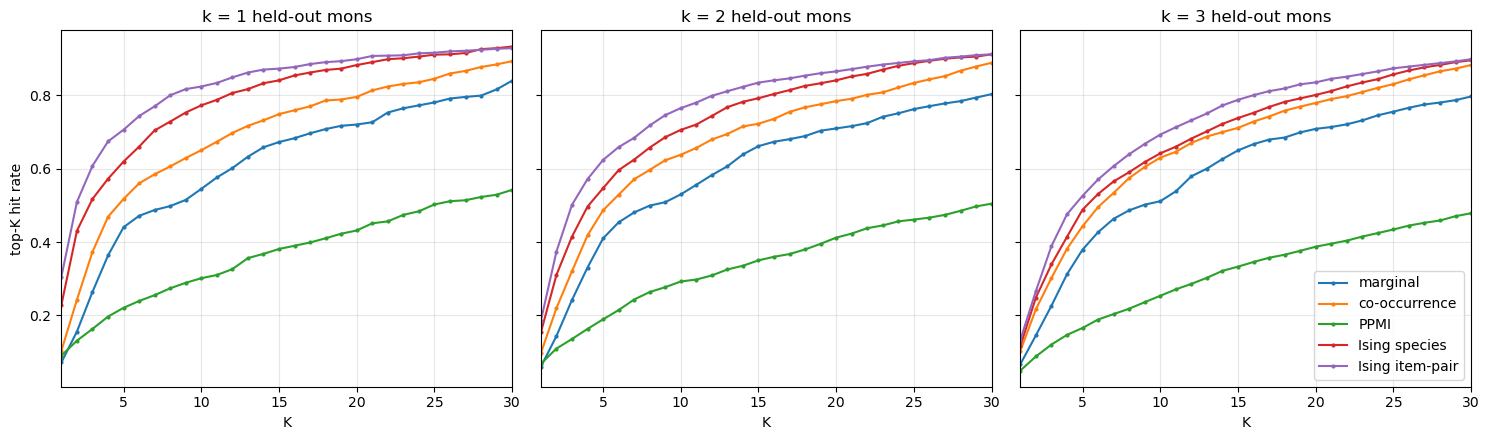

In [26]:
K_RANGE = list(range(1, 31))

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(15, 4.5), sharey=True)
for ax, k in zip(axes, K_VALUES):
    for name in all_models:
        ranks = results[name][k]
        hits = [hit_rate_at_k(ranks, K) for K in K_RANGE]
        ax.plot(K_RANGE, hits, label=name, marker=".", markersize=4)
    ax.set_xlabel("K")
    ax.set_title(f"k = {k} held-out mons")
    ax.grid(alpha=0.3)
    ax.set_xlim(1, K_RANGE[-1])
axes[0].set_ylabel("top-K hit rate")
axes[-1].legend(loc="lower right")
plt.tight_layout()
plt.show()

## Pair-prediction metric (Phase 3 only)

The cross-model evaluation above projects Phase 3's pair predictions down to species granularity so it can compete with the species-only models. That measures one specific question — "does adding item information help species prediction" — but ignores the other thing the item-pair model lets us do: **predict the held-out species AND its item jointly**.

The species-only model literally cannot answer this; there's no way to score a `(species, item)` pair when items aren't features. So this is a Phase-3-vs-Phase-3-baselines comparison: pair-marginal and pair-co-occurrence are the natural counterparts to the species-level marginal/co-occurrence baselines (PPMI omitted — clearly the wrong baseline per prior results).

Held-out pairs are sampled with the same `SEED` and same positions as the species evaluation, but ranked against the full pair vocab with two masks applied:
- Held-in **species** are masked out (no two Charizards).
- Held-in **items** are masked out (no two Choice Specs).

The held-out pair, by team construction, satisfies both — so it's a valid candidate. The interesting numbers here are top-1 / MRR: how often can the model identify the *specific* `(species, item)` build held out, not just the species. Top-1 hit rate is upper-bounded by what the species model gets *times* the probability of guessing the right item conditional on the right species, so absolute numbers will be substantially lower than the species table; the model-vs-baseline gap is what matters.

In [27]:
# Pair-level training matrices for the pair-marginal / pair-co-occurrence baselines.
m_train_pair = X_train_pair.mean(axis=0)
C_train_pair = (X_train_pair_int.T @ X_train_pair_int).astype(np.float64)
np.fill_diagonal(C_train_pair, 0.0)

# Lookup arrays for fast uniqueness masking inside the eval loop.
pair_species_idx = np.array(
    [name_to_idx.get(sp, -1) for sp, _ in pair_vocab], dtype=np.int32
)
all_items_sorted = sorted({it for _, it in pair_vocab if it is not None})
item_to_id = {it: i for i, it in enumerate(all_items_sorted)}
pair_item_id = np.array(
    [item_to_id.get(it, -1) for _, it in pair_vocab], dtype=np.int32
)

print(f"pair vocab size:       {V_pair}")
print(f"distinct items:        {len(all_items_sorted)}")
print(f"m_train_pair range:    [{m_train_pair.min():.4f}, {m_train_pair.max():.4f}]")
print(f"C_train_pair off-diag: max = {int(C_train_pair.max())}, nnz = {int((C_train_pair > 0).sum())}")

pair vocab size:       658
distinct items:        111
m_train_pair range:    [0.0004, 0.3946]
C_train_pair off-diag: max = 1273, nnz = 50652


In [28]:
def score_pair_marginal(held_in_pair_idx, *, m_pair):
    return m_pair.copy()


def score_pair_cooccurrence(held_in_pair_idx, *, C_pair):
    return C_pair[:, list(held_in_pair_idx)].sum(axis=1)


def score_pair_ising_mf(held_in_pair_idx, *, J_pair, h_pair):
    return score_ising_meanfield(held_in_pair_idx, J=J_pair, h=h_pair)

In [29]:
# Restart RNG at same seed so held-out positions match the species evaluation above.
rng_pair = np.random.default_rng(SEED)

pair_scorers = {
    "marginal-pair":      lambda hi: score_pair_marginal(hi, m_pair=m_train_pair),
    "co-occurrence-pair": lambda hi: score_pair_cooccurrence(hi, C_pair=C_train_pair),
    "Ising pair":         lambda hi: score_pair_ising_mf(hi, J_pair=J_pair, h_pair=h_pair),
}

pair_results = {name: {k: [] for k in K_VALUES} for name in pair_scorers}

for team in in_vocab_test:
    members = sorted(team, key=lambda p: p[0])
    pair_idxs = np.array([pair_to_idx[p] for p in members])

    for k in K_VALUES:
        held_out_pos = rng_pair.choice(6, size=k, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_in_pair_idx = pair_idxs[held_in_pos]
        held_out_pair_idx = pair_idxs[held_out_pos]

        # Uniqueness mask: any candidate pair sharing a species or item with a
        # held-in pair is invalid. Held-in pairs are masked by the species sweep.
        held_in_species_ids = pair_species_idx[held_in_pair_idx]
        held_in_item_ids = pair_item_id[held_in_pair_idx]
        held_in_item_ids = held_in_item_ids[held_in_item_ids >= 0]
        invalid_mask = (
            np.isin(pair_species_idx, held_in_species_ids)
            | np.isin(pair_item_id, held_in_item_ids)
        )

        for name, scorer in pair_scorers.items():
            scores = scorer(held_in_pair_idx).astype(np.float64).copy()
            scores[invalid_mask] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V_pair, dtype=np.int64)
            rank_of[order] = np.arange(1, V_pair + 1)
            pair_results[name][k].append(rank_of[held_out_pair_idx])

for name in pair_scorers:
    for k in K_VALUES:
        pair_results[name][k] = np.array(pair_results[name][k])

print(f"evaluated {len(in_vocab_test)} teams x {len(K_VALUES)} k values x {len(pair_scorers)} pair-level models")

evaluated 1128 teams x 3 k values x 3 pair-level models


In [30]:
header = f"{'model':<22} {'k':>2}  {'MRR':>6}  " + "  ".join(f"top-{K:>2}" for K in TOP_K_THRESHOLDS)
print(header)
print("-" * len(header))
for name in pair_scorers:
    for k in K_VALUES:
        ranks = pair_results[name][k]
        row = f"{name:<22} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS)
        print(row)
    print()

model                   k     MRR  top- 1  top- 5  top-10  top-20
-----------------------------------------------------------------
marginal-pair           1   0.168    5.9%   26.6%   34.0%   51.6%
marginal-pair           2   0.152    4.9%   24.5%   34.0%   50.0%
marginal-pair           3   0.141    5.1%   22.3%   31.4%   45.7%

co-occurrence-pair      1   0.242   11.2%   37.1%   54.4%   69.3%
co-occurrence-pair      2   0.225    9.8%   35.8%   50.8%   66.1%
co-occurrence-pair      3   0.201    8.2%   31.1%   46.1%   63.1%

Ising pair              1   0.399   25.9%   56.7%   68.6%   77.0%
Ising pair              2   0.298   14.7%   46.6%   61.3%   73.4%
Ising pair              3   0.222   10.0%   34.5%   48.8%   63.6%



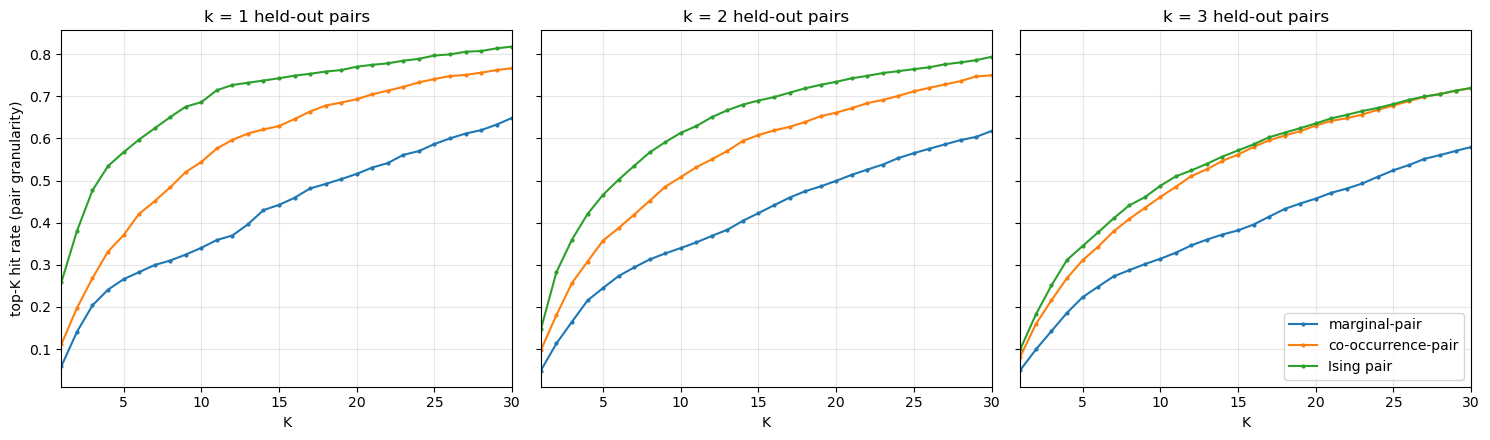

In [31]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(15, 4.5), sharey=True)
for ax, k in zip(axes, K_VALUES):
    for name in pair_scorers:
        ranks = pair_results[name][k]
        hits = [hit_rate_at_k(ranks, K) for K in K_RANGE]
        ax.plot(K_RANGE, hits, label=name, marker=".", markersize=4)
    ax.set_xlabel("K")
    ax.set_title(f"k = {k} held-out pairs")
    ax.grid(alpha=0.3)
    ax.set_xlim(1, K_RANGE[-1])
axes[0].set_ylabel("top-K hit rate (pair granularity)")
axes[-1].legend(loc="lower right")
plt.tight_layout()
plt.show()

## Mean-field vs true sampling (pair prediction, ~100 teams)

The eval above uses **mean-field iteration** to compute Ising-pair marginals — fast, deterministic, and ranking-faithful for the team-size constraint, but it factorizes the joint over candidate pairs (each candidate's marginal is computed assuming others are independent). The webapp's PT-MCMC sampler doesn't make that approximation: it samples joint team configurations from the true Ising distribution.

This cell answers the obvious question: **how good is MF actually as a proxy for the sampler?** If the two agree closely (matching top-1 picks, high rank correlation), MF is a faithful and ~100× cheaper replacement and the eval table above is trustworthy. If they diverge — especially at $k \geq 2$ where joint structure between held-out slots matters — the MF eval is undercounting Ising's headline performance.

**Setup**: first 100 in-vocab test teams, same `SEED` so held-out positions match the main pair eval exactly. Four scorers compared on the same problem:

- `marginal-pair` (baseline)
- `co-occurrence-pair` (baseline)
- `Ising pair (MF)` — what the validator uses
- `Ising pair (MCMC)` — single-chain swap-move MCMC at $\text{fw}=1$, $T=1$, 2000 burn-in + 20000 sample steps. Matches the webapp sampler's target distribution at default operating point (no PT needed at $T=1$ — the regime where parallel tempering matters is low $T$ per CLAUDE.md, not here).

Outputs are the usual hit-rate / MRR table for all four, plus a head-to-head MF-vs-MCMC agreement table (top-1 match rate + Spearman rank correlation) which is the cleanest read on "does MF lose anything."

In [32]:
def pair_mcmc_marginal(
    held_in_pair_idx, k_free, *,
    J_pair, h_pair, pair_species_idx, pair_item_id,
    n_burn, n_sample, seed,
):
    """Swap-move MCMC at field_weight=1, T=1 over k_free free slots conditional
    on held_in_pair_idx fixed. Returns length-V marginal frequencies of each pair
    appearing in any free slot across post-burn-in samples.

    This is the same target distribution `app.py:parallel_tempered_mcmc` samples
    from at fw=1, T=1, just with a simpler single-chain implementation since at
    T=1 there's no multi-modality to defeat. Uniqueness (no duplicate species,
    no duplicate item) is enforced by proposal rejection -- matches the app's
    sampler logic.
    """
    rng = np.random.default_rng(seed)
    V = h_pair.shape[0]
    held_in_arr = np.asarray(held_in_pair_idx, dtype=np.int64)

    held_in_sp = {int(s) for s in pair_species_idx[held_in_arr]}
    held_in_it = {int(x) for x in pair_item_id[held_in_arr] if x >= 0}

    # Greedy init: walk shuffled vocab, take first k_free that don't conflict.
    pool = np.arange(V)
    rng.shuffle(pool)
    used_sp, used_it = set(held_in_sp), set(held_in_it)
    free: list[int] = []
    for cand in pool:
        sp = int(pair_species_idx[cand])
        it = int(pair_item_id[cand])
        if sp in used_sp:
            continue
        if it >= 0 and it in used_it:
            continue
        free.append(int(cand))
        used_sp.add(sp)
        if it >= 0:
            used_it.add(it)
        if len(free) == k_free:
            break
    if len(free) < k_free:
        return np.zeros(V)
    free = np.array(free, dtype=np.int64)

    # Maintain incremental species/item membership across the full team for
    # O(1) uniqueness checks inside the chain.
    team_sp = set(held_in_sp)
    team_it = set(held_in_it)
    for f in free:
        team_sp.add(int(pair_species_idx[f]))
        it = int(pair_item_id[f])
        if it >= 0:
            team_it.add(it)

    counts = np.zeros(V, dtype=np.int64)
    n_total = n_burn + n_sample

    for step in range(n_total):
        slot = int(rng.integers(k_free))
        i_out = int(free[slot])
        sp_out = int(pair_species_idx[i_out])
        it_out = int(pair_item_id[i_out])

        i_in = int(rng.integers(V))
        accept = False
        if i_in != i_out:
            sp_in = int(pair_species_idx[i_in])
            it_in = int(pair_item_id[i_in])
            # Uniqueness vs team minus the slot we're swapping out
            sp_ok = (sp_in == sp_out) or (sp_in not in team_sp)
            it_ok = (it_in < 0) or (it_in == it_out) or (it_in not in team_it)
            if sp_ok and it_ok:
                # delta_E = -h(i_in) + h(i_out) - J[i_in, other].sum() + J[i_out, other].sum()
                # where `other` is the rest of the team (held-in + other free slots).
                other_free = np.delete(free, slot)
                team_other = np.concatenate([held_in_arr, other_free])
                delta_E = (
                    -h_pair[i_in] + h_pair[i_out]
                    - J_pair[i_in, team_other].sum()
                    + J_pair[i_out, team_other].sum()
                )
                if delta_E <= 0 or rng.random() < np.exp(-delta_E):
                    accept = True

        if accept:
            free[slot] = i_in
            team_sp.discard(sp_out)
            team_sp.add(int(pair_species_idx[i_in]))
            if it_out >= 0:
                team_it.discard(it_out)
            if pair_item_id[i_in] >= 0:
                team_it.add(int(pair_item_id[i_in]))

        if step >= n_burn:
            for f in free:
                counts[int(f)] += 1

    total = counts.sum()
    return counts.astype(np.float64) / total if total > 0 else counts.astype(np.float64)

In [33]:
# Comparison subset: first COMPARE_N teams from in_vocab_test, with held-out
# positions matching the main pair eval (same SEED, same iteration order, same
# first N teams). Each problem evaluated by all four methods.
COMPARE_N = 100
N_BURN = 2000
N_SAMPLE = 20000

rng_compare = np.random.default_rng(SEED)
compare_teams = in_vocab_test[:COMPARE_N]

compare_methods = ["marginal-pair", "co-occurrence-pair", "Ising pair (MF)", "Ising pair (MCMC)"]
compare_results = {name: {k: [] for k in K_VALUES} for name in compare_methods}

for ti, team in enumerate(compare_teams):
    members = sorted(team, key=lambda p: p[0])
    pair_idxs = np.array([pair_to_idx[p] for p in members])

    for k in K_VALUES:
        held_out_pos = rng_compare.choice(6, size=k, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_in_pair_idx = pair_idxs[held_in_pos]
        held_out_pair_idx = pair_idxs[held_out_pos]

        # Shared uniqueness mask (applied identically to all four scorers)
        held_in_species_ids = pair_species_idx[held_in_pair_idx]
        held_in_item_ids = pair_item_id[held_in_pair_idx]
        held_in_item_ids_valid = held_in_item_ids[held_in_item_ids >= 0]
        invalid_mask = (
            np.isin(pair_species_idx, held_in_species_ids)
            | np.isin(pair_item_id, held_in_item_ids_valid)
        )

        # Closed-form scorers
        method_scores = {
            "marginal-pair":      score_pair_marginal(held_in_pair_idx, m_pair=m_train_pair),
            "co-occurrence-pair": score_pair_cooccurrence(held_in_pair_idx, C_pair=C_train_pair),
            "Ising pair (MF)":    score_pair_ising_mf(held_in_pair_idx, J_pair=J_pair, h_pair=h_pair),
        }
        # MCMC scorer: distinct seed per (team, k) so chains are independent
        method_scores["Ising pair (MCMC)"] = pair_mcmc_marginal(
            held_in_pair_idx, k_free=k,
            J_pair=J_pair, h_pair=h_pair,
            pair_species_idx=pair_species_idx, pair_item_id=pair_item_id,
            n_burn=N_BURN, n_sample=N_SAMPLE,
            seed=SEED + ti * 100 + k,
        )

        for name, scores_raw in method_scores.items():
            scores = scores_raw.astype(np.float64).copy()
            scores[invalid_mask] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V_pair, dtype=np.int64)
            rank_of[order] = np.arange(1, V_pair + 1)
            compare_results[name][k].append(rank_of[held_out_pair_idx])

    if (ti + 1) % 10 == 0:
        print(f"  team {ti + 1} / {COMPARE_N}")

for name in compare_methods:
    for k in K_VALUES:
        compare_results[name][k] = np.array(compare_results[name][k])

print(f"\nevaluated {COMPARE_N} teams x {len(K_VALUES)} k values x {len(compare_methods)} methods")

  team 10 / 100
  team 20 / 100
  team 30 / 100
  team 40 / 100
  team 50 / 100
  team 60 / 100
  team 70 / 100
  team 80 / 100
  team 90 / 100
  team 100 / 100

evaluated 100 teams x 3 k values x 4 methods


In [34]:
from scipy.stats import spearmanr

print(f"{'method':<22} {'k':>2}  {'MRR':>6}  " + "  ".join(f"top-{K:>2}" for K in TOP_K_THRESHOLDS))
print("-" * 60)
for name in compare_methods:
    for k in K_VALUES:
        ranks = compare_results[name][k]
        row = f"{name:<22} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS)
        print(row)
    print()

# Direct MF-vs-MCMC agreement: how often do they rank the same pair #1, and how
# correlated are their full rankings? Low agreement = MF is throwing away signal
# the sampler captures; high agreement = MF is a faithful (and much faster) proxy.
print("MF vs MCMC agreement (per-team, same held-out problem)")
print(f"{'k':>2}  {'top-1 match':>11}  {'rank Spearman ρ (median)':>26}")
print("-" * 45)
for k in K_VALUES:
    mf_ranks = compare_results["Ising pair (MF)"][k]
    mc_ranks = compare_results["Ising pair (MCMC)"][k]
    # At k=1 each held-out slot gives one rank per method, so direct compare;
    # at k>1, ranks are arrays of length k -- compare position 0 for top-1 match.
    if k == 1:
        mf_top = (mf_ranks.flatten() == 1)
        mc_top = (mc_ranks.flatten() == 1)
        top1_match = float((mf_top & mc_top).sum() / max((mf_top | mc_top).sum(), 1))
        # Spearman over the (n_teams) vector of held-out-pair ranks
        rho, _ = spearmanr(mf_ranks.flatten(), mc_ranks.flatten())
    else:
        mf_top1 = mf_ranks[:, 0] == 1
        mc_top1 = mc_ranks[:, 0] == 1
        top1_match = float((mf_top1 & mc_top1).sum() / max((mf_top1 | mc_top1).sum(), 1))
        rho, _ = spearmanr(mf_ranks.flatten(), mc_ranks.flatten())
    print(f"{k:>2}  {top1_match:>10.1%}  {rho:>26.3f}")

method                  k     MRR  top- 1  top- 5  top-10  top-20
------------------------------------------------------------
marginal-pair           1   0.243   13.0%   35.0%   38.0%   57.0%
marginal-pair           2   0.191    7.5%   31.5%   37.5%   54.5%
marginal-pair           3   0.169    7.7%   26.7%   33.0%   51.7%

co-occurrence-pair      1   0.334   20.0%   47.0%   60.0%   76.0%
co-occurrence-pair      2   0.300   17.0%   45.5%   56.0%   75.0%
co-occurrence-pair      3   0.253   13.3%   36.3%   50.7%   70.7%

Ising pair (MF)         1   0.519   36.0%   70.0%   79.0%   88.0%
Ising pair (MF)         2   0.382   20.0%   62.0%   73.5%   84.0%
Ising pair (MF)         3   0.269   14.0%   40.3%   58.0%   71.0%

Ising pair (MCMC)       1   0.524   36.0%   72.0%   80.0%   90.0%
Ising pair (MCMC)       2   0.394   22.0%   62.5%   75.5%   84.5%
Ising pair (MCMC)       3   0.274   13.0%   43.3%   62.0%   73.3%

MF vs MCMC agreement (per-team, same held-out problem)
 k  top-1 match    ran

## Interpretation

Three independent comparisons to read off the table + plot:

1. **Sanity ordering**: marginal < co-occurrence < Ising species. If this is violated, the harness is wrong. PPMI is expected to be off the bottom (it's the wrong distributional measure for completion — see CLAUDE.md), but should at least be consistent across $k$.
2. **Ising species vs co-occurrence** (the Phase A headline): margin tells you whether structural inference is doing work beyond direct co-occurrence. Established by prior runs at ~5–8 pp on top-K hit rate, ~1.5× on MRR at $k=1$.
3. **Ising item-pair vs Ising species** (the Phase D headline): tells you whether the item-pair extension is worth the implementation cost (cache invalidation, sampler surgery, ~5× vocab size). If item-pair beats species at $k=1$ by a comparable margin to species over co-occurrence, the extension compounds value. If it ties or loses, the bottleneck isn't item granularity — revisit feature richness (abilities, moves), corpus size, or model class.

Decision points based on the numbers:

- **Item-pair clearly wins** (≥3 pp on top-1, ≥0.05 on MRR at $k=1$): item context matters and we should keep building in this direction (next: abilities / tera as additional features).
- **Item-pair ties species** (within ~1 pp / 0.02 MRR): item information is theoretically sound but not differentiating at this corpus size; vocab grew without buying accuracy. Possible explanations: items are too correlated with species (one dominant item per mon), the corpus is too small to resolve fine-grained pair couplings, or the model class is the bottleneck.
- **Item-pair loses to species**: surprising and worth investigating. Most likely explanation is that the pair vocab dilutes effective sample size per feature — each pair has fewer positive examples than its parent species, increasing variance enough to wash out the resolution gain.

A complementary pair-level cut is given by the pair-prediction table above: there the question is "can the model identify the *specific* `(species, item)` build", which only Phase 3 can answer; the relevant comparison is Phase 3 vs the pair-marginal / pair-co-occurrence baselines.